# Анализ результатов профилировщика rl-scheduler

Строим три группы графиков по данным из `profile_results.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

CSV_PATH = Path('../cluster/profile_results.csv')

raw = pd.read_csv(CSV_PATH)

# Оставляем только успешные измерения
df = raw[raw['error'].isna() & raw['duration_ms'].notna()].copy()
df['duration_ms'] = df['duration_ms'].astype(float)

# Читаемая метка воркера: worker1, worker2, …
df['worker_label'] = df['worker'].str.extract(r'^(worker\d+)')

# Порядок воркеров по возрастанию лимита CPU
worker_order = (
    df.groupby('worker_label')['cpu_limit_cores']
    .first()
    .sort_values()
    .index.tolist()
)

# Лимиты CPU для подписей
worker_cpu_limit = (
    df.groupby('worker_label')['cpu_limit_cores']
    .first()
    .to_dict()
)

TASK_TYPES = sorted(df['task_type'].unique())

print('Воркеры (по возрастанию CPU-лимита):')
for w in worker_order:
    print(f'  {w}: {worker_cpu_limit[w]:.2f} cores')
print('\nТипы задач:', TASK_TYPES)

Воркеры (по возрастанию CPU-лимита):
  worker1: 0.30 cores
  worker2: 0.50 cores
  worker3: 0.80 cores
  worker4: 1.00 cores
  worker5: 1.50 cores
  worker6: 2.00 cores

Типы задач: ['mat_mul', 'monte_carlo', 'prime_sieve']


## 1. Среднее время выполнения задачи на воркере в зависимости от размера входных данных

Один подграфик на каждый тип задачи. Линия — один воркер.

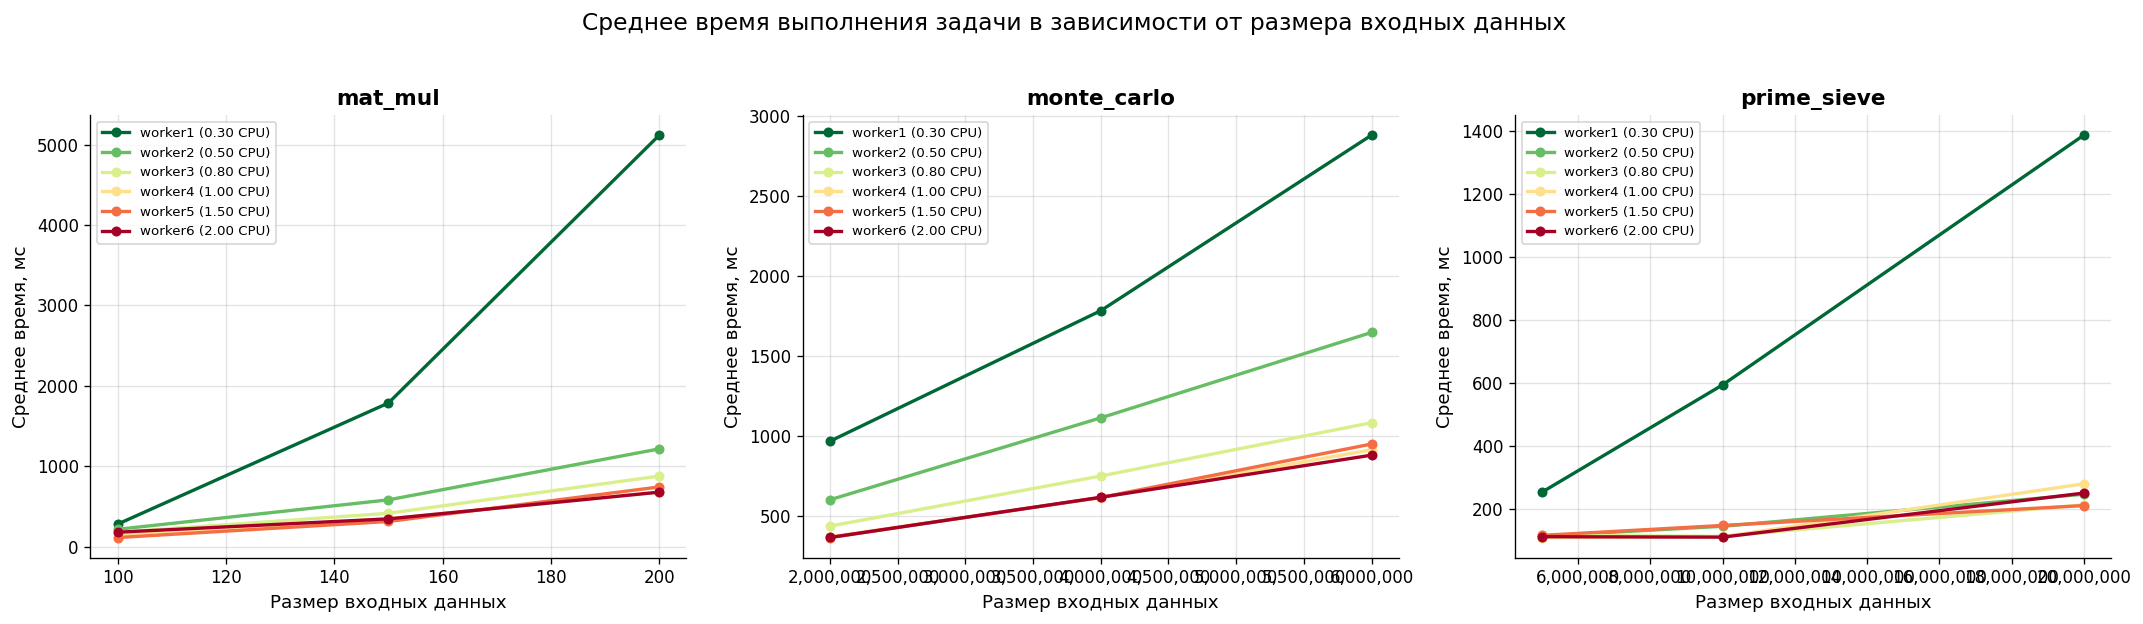

In [2]:
mean_df = (
    df.groupby(['task_type', 'worker_label', 'size'])['duration_ms']
    .mean()
    .reset_index()
    .rename(columns={'duration_ms': 'mean_ms'})
)

# Цвета по воркерам — от синего (слабый) до красного (сильный)
cmap = plt.colormaps['RdYlGn_r']
colors = {w: cmap(i / (len(worker_order) - 1)) for i, w in enumerate(worker_order)}

n_tasks = len(TASK_TYPES)
fig, axes = plt.subplots(1, n_tasks, figsize=(6 * n_tasks, 5), sharey=False)
if n_tasks == 1:
    axes = [axes]

for ax, task in zip(axes, TASK_TYPES):
    sub = mean_df[mean_df['task_type'] == task]
    for w in worker_order:
        wdata = sub[sub['worker_label'] == w].sort_values('size')
        if wdata.empty:
            continue
        label = f'{w} ({worker_cpu_limit[w]:.2f} CPU)'
        ax.plot(
            wdata['size'], wdata['mean_ms'],
            marker='o', linewidth=2, markersize=5,
            color=colors[w], label=label
        )
    ax.set_title(task, fontsize=13, fontweight='bold')
    ax.set_xlabel('Размер входных данных', fontsize=11)
    ax.set_ylabel('Среднее время, мс', fontsize=11)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend(fontsize=8, loc='upper left')

fig.suptitle(
    'Среднее время выполнения задачи в зависимости от размера входных данных',
    fontsize=14, y=1.03
)
plt.tight_layout()
plt.savefig('plot1_duration_vs_size.png', bbox_inches='tight')
plt.show()

## 2. Среднее время выполнения задачи (конкретный размер) в зависимости от воркера

Один подграфик на каждый тип задачи. Группы полос — разные размеры входных данных.

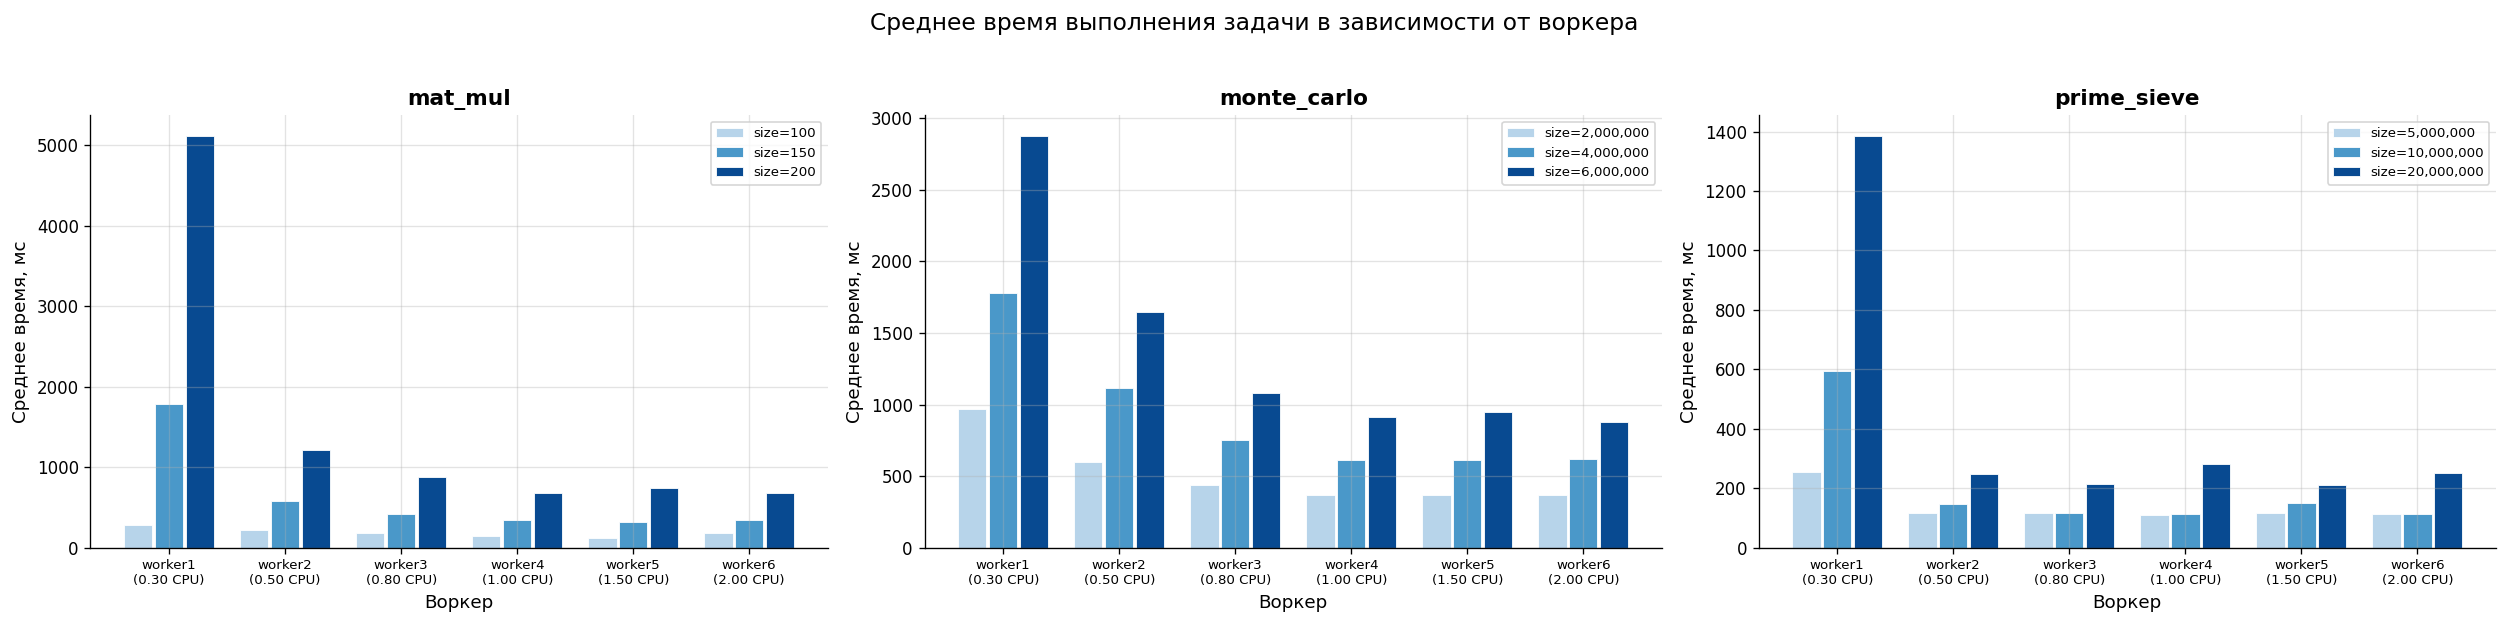

In [3]:
fig, axes = plt.subplots(1, n_tasks, figsize=(7 * n_tasks, 5), sharey=False)
if n_tasks == 1:
    axes = [axes]

for ax, task in zip(axes, TASK_TYPES):
    sub = mean_df[mean_df['task_type'] == task]
    sizes = sorted(sub['size'].unique())
    n_sizes = len(sizes)

    size_cmap = plt.colormaps['Blues']
    size_colors = [
        size_cmap(0.3 + 0.6 * i / max(n_sizes - 1, 1))
        for i in range(n_sizes)
    ]

    x = np.arange(len(worker_order))
    width = 0.8 / n_sizes

    for i, (sz, color) in enumerate(zip(sizes, size_colors)):
        vals = []
        for w in worker_order:
            row = sub[(sub['worker_label'] == w) & (sub['size'] == sz)]
            vals.append(row['mean_ms'].values[0] if not row.empty else 0)
        offset = (i - n_sizes / 2 + 0.5) * width
        bars = ax.bar(
            x + offset, vals, width=width * 0.92,
            label=f'size={sz:,}', color=color, edgecolor='white', linewidth=0.5
        )

    ax.set_title(task, fontsize=13, fontweight='bold')
    ax.set_xlabel('Воркер', fontsize=11)
    ax.set_ylabel('Среднее время, мс', fontsize=11)
    ax.set_xticks(x)
    worker_tick_labels = [
        f'{w}\n({worker_cpu_limit[w]:.2f} CPU)' for w in worker_order
    ]
    ax.set_xticklabels(worker_tick_labels, fontsize=8)
    ax.legend(fontsize=8, loc='upper right')

fig.suptitle(
    'Среднее время выполнения задачи в зависимости от воркера',
    fontsize=14, y=1.03
)
plt.tight_layout()
plt.savefig('plot2_duration_vs_worker.png', bbox_inches='tight')
plt.show()

## 3. Метрики воркера (CPU%, RAM) на конкретной задаче в зависимости от размера входных данных

Один блок подграфиков на каждый тип задачи: строки — воркеры, столбцы — CPU% и RAM (MiB).

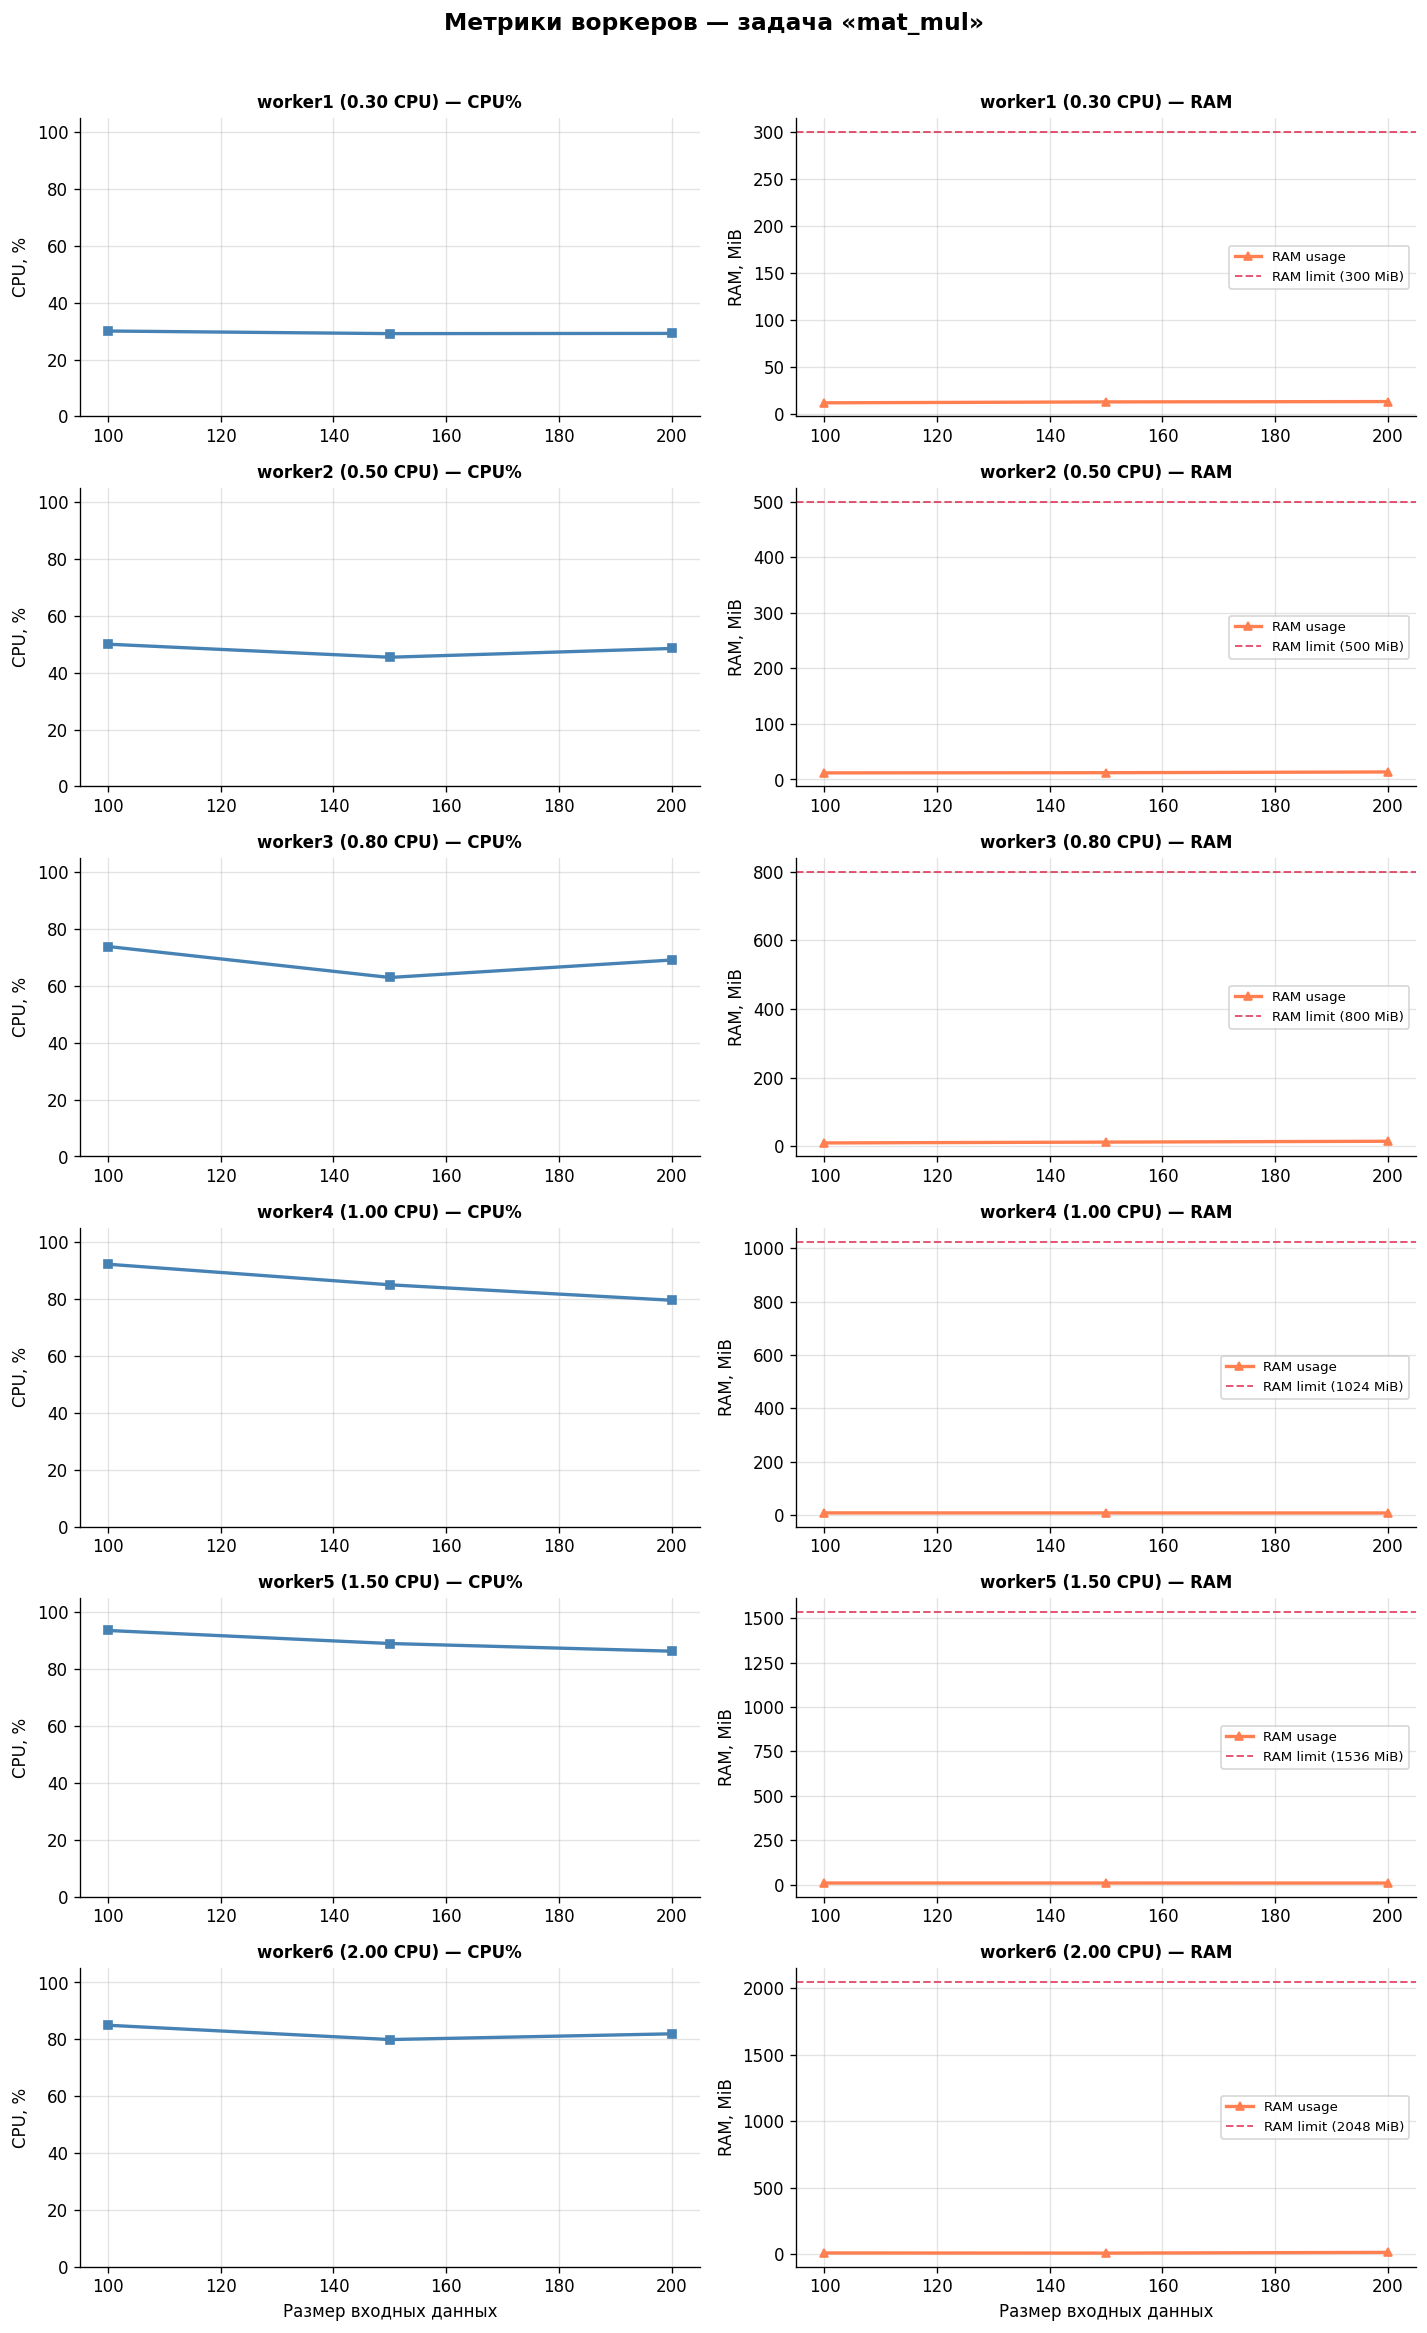

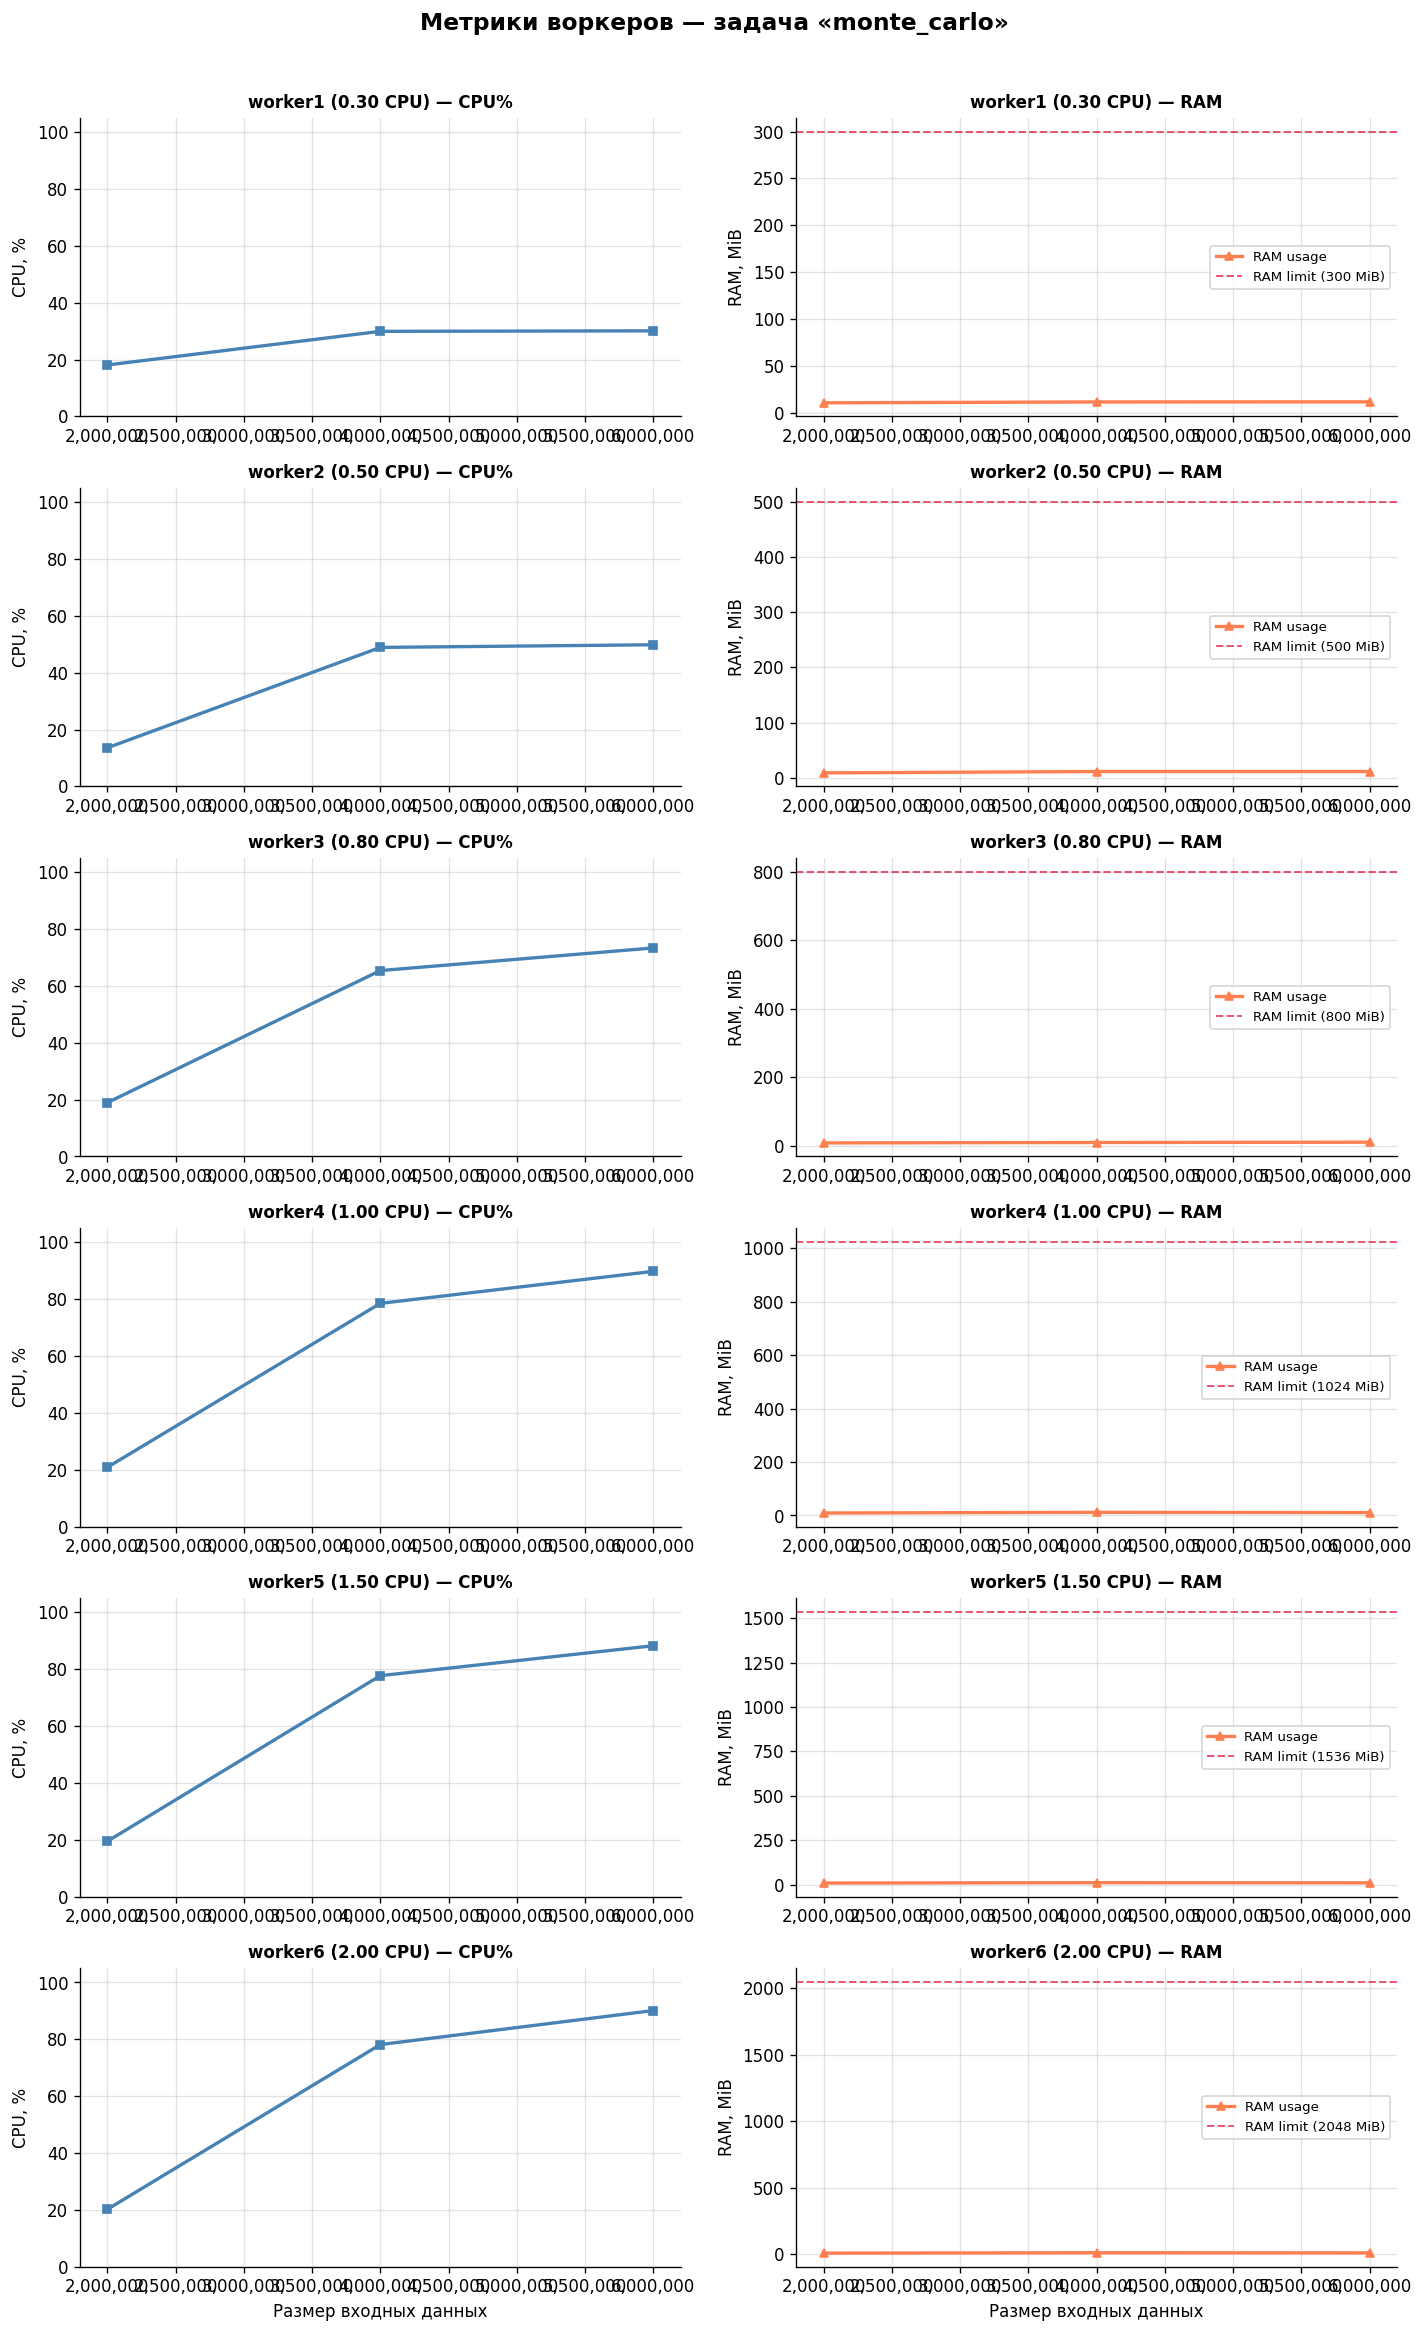

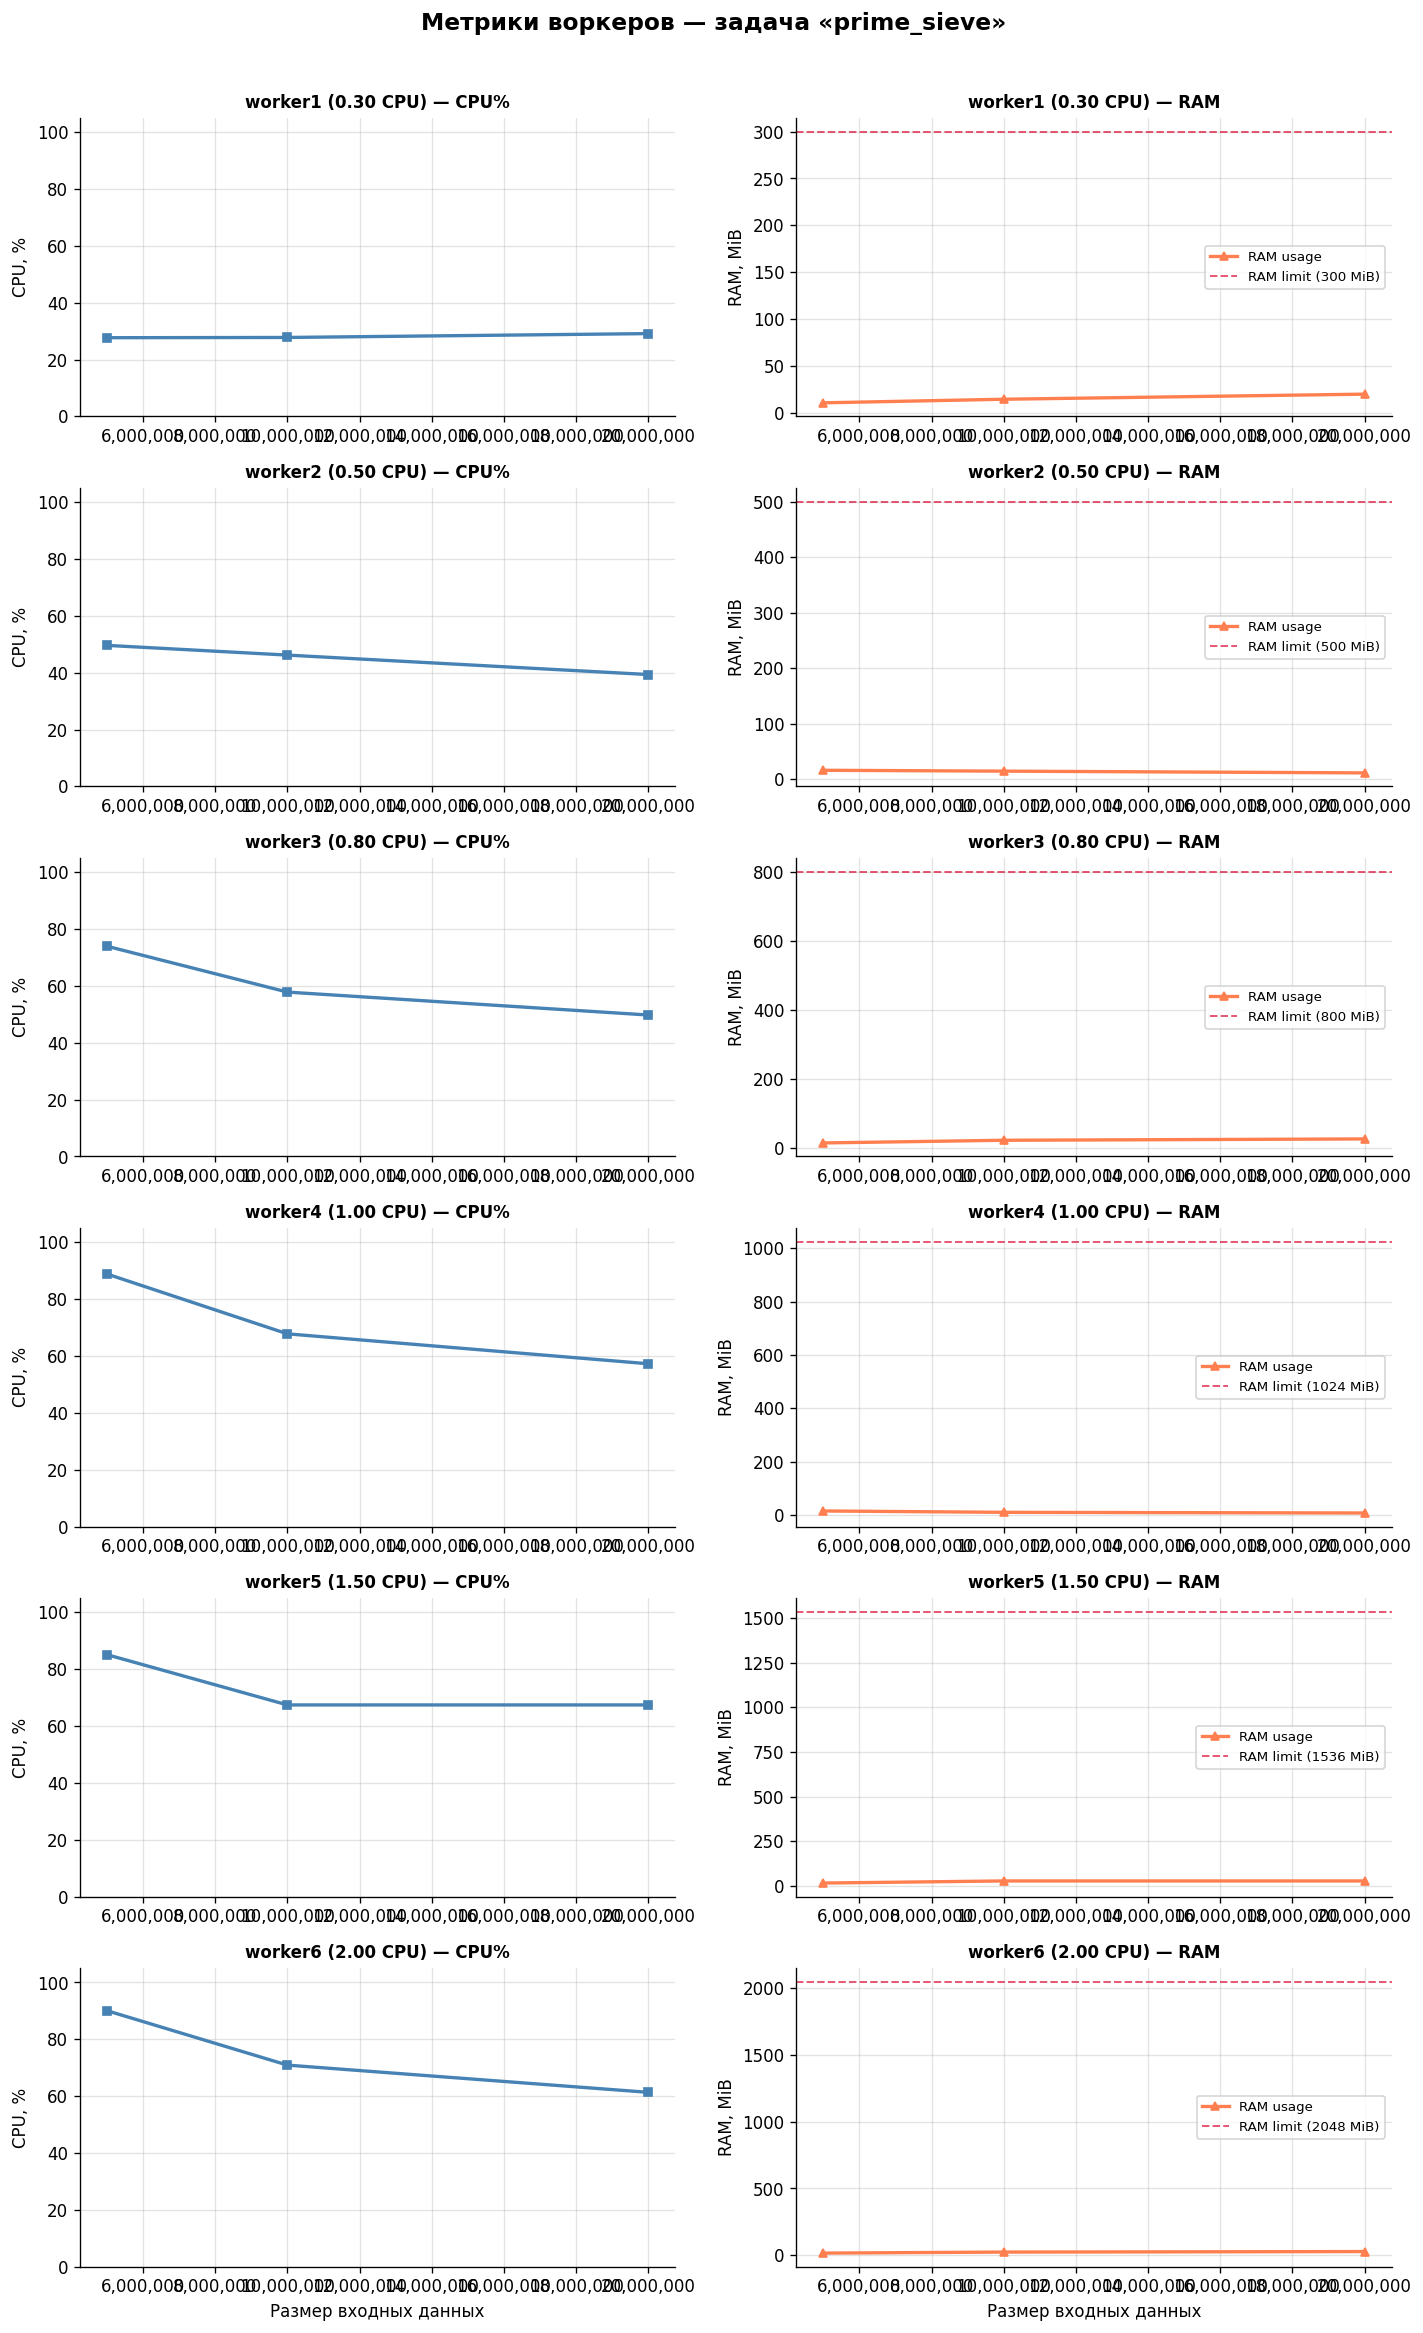

In [4]:
metrics_df = df[df['metrics_error'].isna()].copy()
metrics_df['ram_usage_mib'] = metrics_df['ram_usage_kib'] / 1024

mean_metrics = (
    metrics_df
    .groupby(['task_type', 'worker_label', 'size'])[['cpu_util_pct', 'ram_usage_mib']]
    .mean()
    .reset_index()
)

for task in TASK_TYPES:
    sub = mean_metrics[mean_metrics['task_type'] == task]
    workers_present = [w for w in worker_order if w in sub['worker_label'].values]
    n_workers = len(workers_present)

    if n_workers == 0:
        continue

    fig, axes = plt.subplots(
        n_workers, 2,
        figsize=(12, 3.2 * n_workers),
        sharex='row', squeeze=False
    )

    for row_i, w in enumerate(workers_present):
        wdata = sub[sub['worker_label'] == w].sort_values('size')
        cpu_limit = worker_cpu_limit.get(w, '?')

        # CPU%
        ax_cpu = axes[row_i][0]
        ax_cpu.plot(
            wdata['size'], wdata['cpu_util_pct'],
            marker='s', color='steelblue', linewidth=2, markersize=5
        )
        ax_cpu.set_ylabel('CPU, %', fontsize=10)
        ax_cpu.set_ylim(0, 105)
        ax_cpu.set_title(f'{w} ({cpu_limit:.2f} CPU) — CPU%', fontsize=10, fontweight='bold')
        ax_cpu.xaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
        )
        if row_i == n_workers - 1:
            ax_cpu.set_xlabel('Размер входных данных', fontsize=10)

        # RAM
        ax_ram = axes[row_i][1]
        ram_max_mib = (
            df[df['worker_label'] == w]['ram_max_kib'].iloc[0] / 1024
            if not df[df['worker_label'] == w].empty else None
        )
        ax_ram.plot(
            wdata['size'], wdata['ram_usage_mib'],
            marker='^', color='coral', linewidth=2, markersize=5, label='RAM usage'
        )
        if ram_max_mib is not None:
            ax_ram.axhline(
                ram_max_mib, color='crimson', linestyle='--',
                linewidth=1.2, alpha=0.7, label=f'RAM limit ({ram_max_mib:.0f} MiB)'
            )
            ax_ram.legend(fontsize=8)
        ax_ram.set_ylabel('RAM, MiB', fontsize=10)
        ax_ram.set_title(f'{w} ({cpu_limit:.2f} CPU) — RAM', fontsize=10, fontweight='bold')
        ax_ram.xaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
        )
        if row_i == n_workers - 1:
            ax_ram.set_xlabel('Размер входных данных', fontsize=10)

    fig.suptitle(
        f'Метрики воркеров — задача «{task}»',
        fontsize=14, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.savefig(f'plot3_metrics_{task}.png', bbox_inches='tight')
    plt.show()